## Forest growth model

Population modeling is a fundamental tool in ecology and Earth system science that helps us understand how ecosystems change over time. In this notebook, we will explore the dynamics of forest biomass using two classical population models. Forest ecosystems provide an excellent case study for population dynamics because they exhibit clear patterns of growth, competition for resources, and carrying capacity limitations.

This exercise is a stepping stone toward modeling more complex predator-prey systems like the Rosenzweig-McArthur model, which describes the interaction between consumers and their resources in ecological communities.

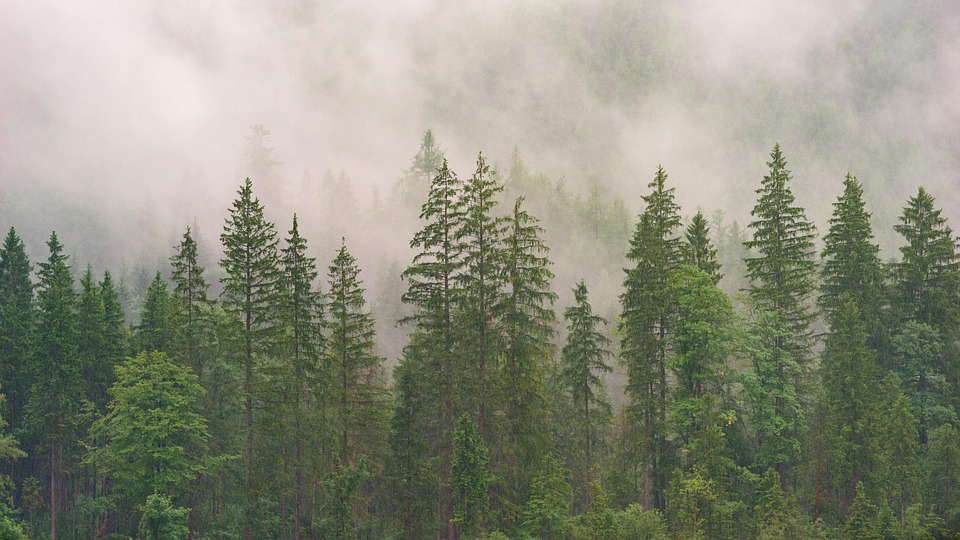

## Forest biomass
Our primary variable of interest is

> 🌲 **Forest Biomass**
>
> $m$: biomass per unit area [$\mathsf{M} \mathsf{L}^{-2}$]
>
> It represents the total mass of living plant material in the forest trees.

Typical values range from 5 kg/m² for a young forest to 50 kg/m² for an old-growth forest.

Our goal will be to describe how $m(t)$ changes over time $t$.

## Model neglecting resource limitations

To get started, we neglect resource limitations. The forest can grow, at a rate governed by its internal ability to build up biomass.

Thinking of the forest as a compartment, the biomass in this compartment changes in response to
- 🌱 **biomass production**: creation of living biomass material due to carbon fixation
- 🍂 **biomass loss**: death and decay of living tissues.

To create a quantitative model, we assume that both biomass production and loss are proportional to the current biomass.

> ⚖️ **Exponential Growth Model**
>
> $\dot{m} = p \cdot m - l \cdot m = r \cdot m$
>
> Where:
> - 🌱 $p$: production rate per unit biomass [$\mathsf{T}^{-1}$]
> - 🍂 $l$: loss rate per unit biomass [$\mathsf{T}^{-1}$]
> - $r = (p - l)$: net growth rate [$\mathsf{T}^{-1}$]



The following code boxes simulate and plot the evolution of biomass $m(t)$ based on this model. The code uses the model's analytical solution: The evolution is described by an exponential function (hence the name).

In [ ]:
#@title Set up plotting

import numpy as np
import matplotlib.pyplot as plt

def plot_exponential_growth(m0, r):
    # Time array
    t = np.linspace(0, 50)

    # Analytical solution for exponential growth: m(t) = m0 * exp(r*t)
    m_exponential = m0 * np.exp(r * t)

    # Create the plot
    plt.figure(figsize=(6, 4))
    plt.plot(t, m_exponential, 'k-', linewidth=2)

    plt.xlabel('Time [y]')
    plt.ylabel('Forest Biomass m(t) [kg/m²]')
    plt.title('Exponential Growth Model: Biomass vs Time')
    plt.xlim(0, t[-1])
    plt.ylim(0, None)

    plt.show()


You can change the initial condition by varying `m0`.

Production rate (p): 0.12 per year
Loss rate (l): 0.07 per year
Net growth rate (r): 0.05 per year


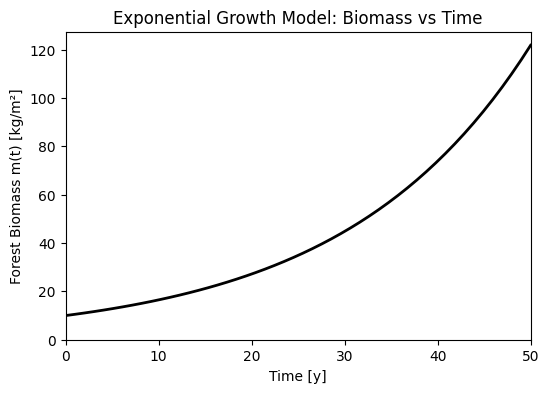

In [10]:
# Model parameters
p = 0.12  # production rate [1/year]
l = 0.07  # loss rate [1/year]
r = p - l # net growth rate [1/year]

print(f"Production rate (p): {p:.2g} per year")
print(f"Loss rate (l): {l:.2g} per year")
print(f"Net growth rate (r): {r:.2g} per year")

# TODO: Set your initial biomass condition here
m0 = 10.0  # initial biomass [kg/m²]; default: 10.0
plot_exponential_growth(m0, r)

The biomass grows exponentially. What is the characteristic time scale of its increase, given a net growth rate of 0.05 per year?

This growth without bounds for $r > 0$ is clearly not realistic, as resources are always limited.

The biomass grows exponentially. What is the characteristic time scale of its increase, given a net growth rate of 0.05 per year?

> 🧪 **Activity: Potential Well Diagrams**
>
> **Instructions:** Draw two potential well diagrams (with biomass on the horizontal axis):
>
> 1. One for the exponential model with the given loss and production rate
> 2. One for a doubled loss rate
>
> For each diagram, indicate the direction and relative rate of biomass change at different biomass values.

## Including resource limitations

In reality, forests cannot grow indefinitely. As biomass increases, competition for resources such as space, sunlight, water, and nutrients intensifies.

We can model this by introducing a **carrying capacity** $K$, which represents the maximum sustainable biomass per unit area that the environment can support. At the carrying capacity, the growth rate is reduced to zero.

> 🌳 **Logistic Growth Model**
>
> $$\dot{m} = r \cdot m \left(1 - \frac{m}{K}\right)$$
>
> Where:
> - $r$: intrinsic growth rate [$\mathsf{T}^{-1}$]
> - $K$: carrying capacity [$\mathsf{M}\mathsf{L}^{-2}$]
> - $\left(1 - \frac{m}{K}\right)$: resource limitation factor
>

This model reduces growth rate as biomass approaches carrying capacity. For small biomass where $m \ll K$, growth is not limited, and the growth rate $\dot{m} / m$ is approximately $r$, the intrinsic growth rate. As $m$ approaches $K$, the effective growth rate decreases, eventually reaching zero when $m = K$.

The following codeboxes plot the biomass as a function of time. It uses an anaytical solution, which involves the so-called logistic function, hence the name of the model.

In [11]:
#@title Set up plotting

def plot_logistic_growth(m0, r, K):
    t = np.linspace(0, 100)

    # Analytical solution for logistic growth: m(t) = K / (1 + ((K-m0)/m0) * exp(-r*t))
    m_logistic = K / (1 + ((K - m0) / m0) * np.exp(-r * t))

    # Create the plot
    plt.figure(figsize=(6, 4))
    plt.axhline(y=K, color='#bbbbbb', linewidth=0.8)
    plt.plot(t, m_logistic, 'k-', linewidth=2)

    plt.xlabel('Time [y]')
    plt.ylabel('Forest Biomass m(t) [kg/m²]')
    plt.title('Logistic Growth Model: Biomass vs Time')
    plt.xlim(0, t[-1])
    plt.ylim(0, None)

    plt.show()

Vary the initial biomass by modifying `m0`

Intrinsic growth rate (r): 0.05 per year
Carrying capacity (K): 25 kg/m²


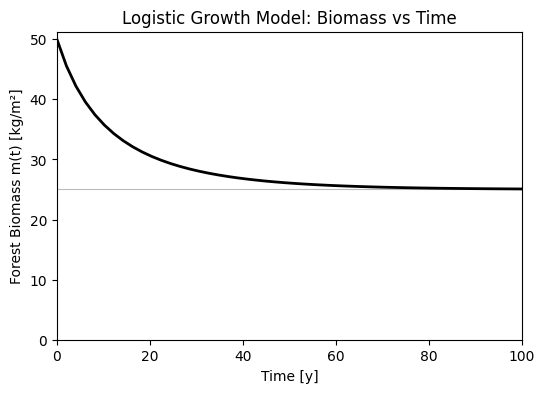

In [20]:
# Logistic Growth Model: Interactive Parameter Exploration

# Model parameters
r = 0.05  # intrinsic growth rate [1/year]
K = 25.0  # carrying capacity [kg/m²]

print(f"Intrinsic growth rate (r): {r:.2g} per year")
print(f"Carrying capacity (K): {K:.2g} kg/m²")

# TODO: Set your initial biomass condition here
m0 = 50  # initial biomass [kg/m²]

plot_logistic_growth(m0, r, K)

> 🤝 **In pairs: Explore Different Initial Conditions**
>
> **Instructions:** Change the initial biomass `m0` in the code above and observe how the biomass changes over time. Include values well below, near, and well above carrying capacity.
>
> **Questions:**
> 1. **Final state:** Where does the biomass end up in each case? What determines this final value?
> 2. **Potential well diagram:** Draw a potential well diagram and read off the direction and rate of biomass change.
> 3. **Biological meaning:** What does it mean biologically when the biomass decreases from an initial value above $K$?
>
> In addition to the simulated dynamics, you can also consider the differential equation and the assumptions we made when we derived it.
